## 1. Setup & Install Library

In [1]:
!pip install kagglehub scikit-image opencv-python-headless -q

import os, json, shutil, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import Sequence
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download Dataset

In [2]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")
print("Path to dataset files:", path)

dataset_root = Path(path)

# Auto-detect folder train/validation/test
train_candidates = list(dataset_root.rglob("train"))
val_candidates   = list(dataset_root.rglob("validation"))
test_candidates  = list(dataset_root.rglob("test"))

TRAIN_DIR = train_candidates[0] if train_candidates else dataset_root/"train"
VAL_DIR   = val_candidates[0]   if val_candidates   else dataset_root/"validation"
TEST_DIR  = test_candidates[0]  if test_candidates  else dataset_root/"test"

print(f"TRAIN_DIR : {TRAIN_DIR} | exists: {TRAIN_DIR.exists()}")
print(f"VAL_DIR   : {VAL_DIR}   | exists: {VAL_DIR.exists()}")
print(f"TEST_DIR  : {TEST_DIR}  | exists: {TEST_DIR.exists()}")


Using Colab cache for faster access to the 'fruit-and-vegetable-image-recognition' dataset.
Path to dataset files: /kaggle/input/fruit-and-vegetable-image-recognition
TRAIN_DIR : /kaggle/input/fruit-and-vegetable-image-recognition/train | exists: True
VAL_DIR   : /kaggle/input/fruit-and-vegetable-image-recognition/validation   | exists: True
TEST_DIR  : /kaggle/input/fruit-and-vegetable-image-recognition/test  | exists: True


## 3. Konfigurasi

In [3]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 30
SEED       = 42
MODEL_PATH = "mobilenetv3_buah_sayur.keras"

# Ambil kelas dari folder train yang ada di val dan test juga
train_cls   = set(d.name for d in TRAIN_DIR.iterdir() if d.is_dir())
val_cls     = set(d.name for d in VAL_DIR.iterdir()   if d.is_dir())
test_cls    = set(d.name for d in TEST_DIR.iterdir()  if d.is_dir())
CLASS_NAMES = sorted(train_cls & val_cls & test_cls)
NUM_CLASSES = len(CLASS_NAMES)

# Hitung jumlah gambar per split
n_tr = sum(len(list((TRAIN_DIR/c).glob("*.*"))) for c in CLASS_NAMES)
n_vl = sum(len(list((VAL_DIR/c).glob("*.*")))   for c in CLASS_NAMES)
n_ts = sum(len(list((TEST_DIR/c).glob("*.*")))  for c in CLASS_NAMES)

print(f"IMG_SIZE    : {IMG_SIZE}")
print(f"BATCH_SIZE  : {BATCH_SIZE}")
print(f"EPOCHS      : {EPOCHS}")
print(f"NUM_CLASSES : {NUM_CLASSES}")
print(f"CLASS_NAMES : {CLASS_NAMES}")
print(f"Train: {n_tr} | Val: {n_vl} | Test: {n_ts}")


IMG_SIZE    : (224, 224)
BATCH_SIZE  : 32
EPOCHS      : 30
NUM_CLASSES : 36
CLASS_NAMES : ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']
Train: 3115 | Val: 351 | Test: 359


## 4. Prapemrosesan Citra
- **Gaussian Filter** — reduksi noise Gaussian
- **Median Filter** — reduksi noise impulsif
- **CLAHE** — peningkatan kontras lokal
- **Contrast Stretching** — perbaikan distribusi intensitas global


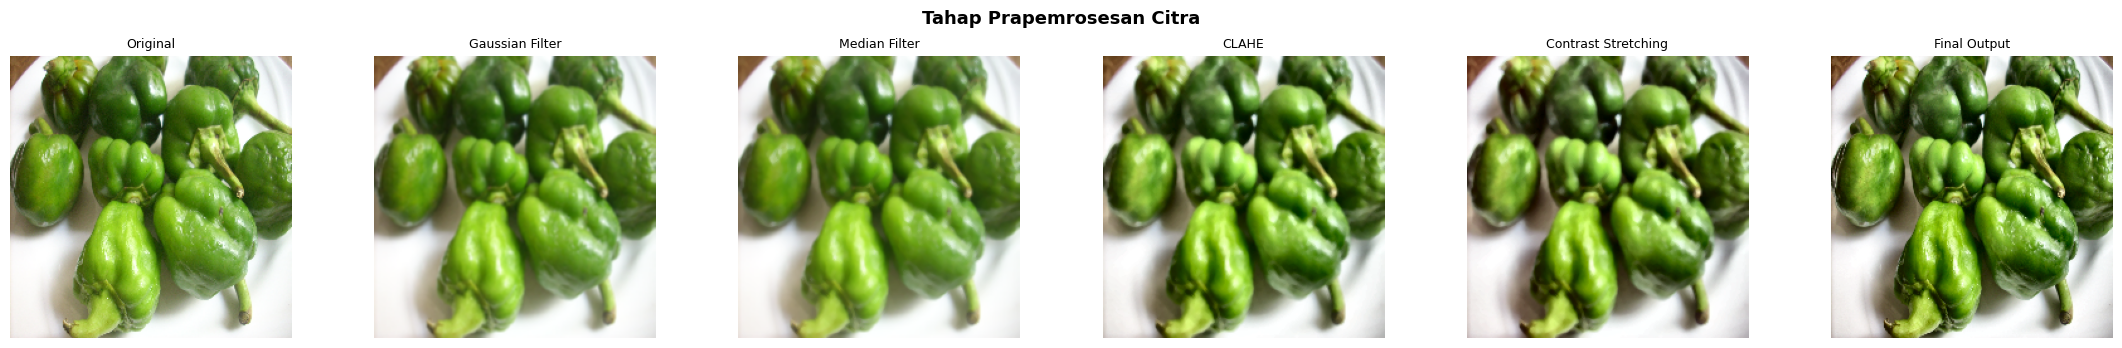

Sampel dari: /kaggle/input/fruit-and-vegetable-image-recognition/train/capsicum/Image_22.jpg


In [4]:
def preprocess_image(img_bgr):
    """
    Input : uint8 BGR numpy array
    Output: float32 RGB numpy array [0,1] ukuran 224x224
    """
    img = img_bgr.copy()

    # 1. Gaussian Filter
    img = cv2.GaussianBlur(img, (3, 3), sigmaX=1.0)

    # 2. Median Filter
    img = cv2.medianBlur(img, 3)

    # 3. CLAHE pada channel L (LAB colorspace)
    lab     = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab     = cv2.merge([clahe.apply(l), a, b])
    img     = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    # 4. Contrast Stretching
    img = img.astype(np.float32)
    for c in range(3):
        mn, mx = img[:, :, c].min(), img[:, :, c].max()
        if mx > mn:
            img[:, :, c] = (img[:, :, c] - mn) / (mx - mn) * 255.0
    img = img.astype(np.uint8)

    # 5. Resize ke 224x224 & konversi RGB
    img = cv2.resize(img, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 6. Normalisasi [0,1]
    return img.astype(np.float32) / 255.0


# Visualisasi tahap prapemrosesan
sample_path = next(TRAIN_DIR.rglob("*.jpg"))
raw         = cv2.imread(str(sample_path))
raw_r       = cv2.resize(raw, IMG_SIZE)

g     = cv2.GaussianBlur(raw_r, (3,3), 1.0)
m     = cv2.medianBlur(g, 3)
lab   = cv2.cvtColor(m, cv2.COLOR_BGR2LAB)
l,a,b = cv2.split(lab)
cl    = cv2.createCLAHE(2.0,(8,8))
ci    = cv2.cvtColor(cv2.merge([cl.apply(l),a,b]), cv2.COLOR_LAB2BGR)
cs    = ci.astype(np.float32)
for ch in range(3):
    mn,mx = cs[:,:,ch].min(), cs[:,:,ch].max()
    if mx>mn: cs[:,:,ch]=(cs[:,:,ch]-mn)/(mx-mn)*255

stages = {
    "Original"           : cv2.cvtColor(raw_r, cv2.COLOR_BGR2RGB),
    "Gaussian Filter"    : cv2.cvtColor(g,     cv2.COLOR_BGR2RGB),
    "Median Filter"      : cv2.cvtColor(m,      cv2.COLOR_BGR2RGB),
    "CLAHE"              : cv2.cvtColor(ci,     cv2.COLOR_BGR2RGB),
    "Contrast Stretching": cv2.cvtColor(cs.astype(np.uint8), cv2.COLOR_BGR2RGB),
    "Final Output"       : (preprocess_image(raw)*255).astype(np.uint8),
}

fig, axes = plt.subplots(1, 6, figsize=(22, 3.5))
for ax, (title, img) in zip(axes, stages.items()):
    ax.imshow(img); ax.set_title(title, fontsize=9); ax.axis('off')
plt.suptitle("Tahap Prapemrosesan Citra", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("preprocessing_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Sampel dari: {sample_path}")


## 5. Persiapan Data Generator

In [5]:
class FruitDataGenerator(Sequence):
    """Custom generator — normalisasi hanya sekali di preprocess_image."""
    def __init__(self, data_dir, class_names, batch_size=32,
                 augment=False, shuffle=True, seed=42):
        self.data_dir    = Path(data_dir)
        self.class_names = class_names
        self.class_map   = {c: i for i, c in enumerate(class_names)}
        self.batch_size  = batch_size
        self.augment     = augment
        self.shuffle     = shuffle

        self.samples = []
        for cls in class_names:
            cls_dir = self.data_dir / cls
            if not cls_dir.exists(): continue
            for p in list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.jpeg")) + list(cls_dir.glob("*.png")):
                self.samples.append((str(p), self.class_map[cls]))

        self.indices = np.arange(len(self.samples))
        if shuffle:
            np.random.seed(seed)
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []
        for i in batch_idx:
            path, label = self.samples[i]
            img = cv2.imread(path)
            if img is None: continue
            img = preprocess_image(img)
            if self.augment:
                if np.random.rand() > 0.5:
                    img = img[:, ::-1, :]
                img = np.clip(img * np.random.uniform(0.85, 1.15), 0, 1)
            X.append(img)
            y.append(label)
        return (np.array(X, np.float32),
                keras.utils.to_categorical(y, len(self.class_names)))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


train_gen = FruitDataGenerator(TRAIN_DIR, CLASS_NAMES, BATCH_SIZE, augment=True,  shuffle=True)
val_gen   = FruitDataGenerator(VAL_DIR,   CLASS_NAMES, BATCH_SIZE, augment=False, shuffle=False)
test_gen  = FruitDataGenerator(TEST_DIR,  CLASS_NAMES, BATCH_SIZE, augment=False, shuffle=False)

print(f"Train : {len(train_gen.samples)} gambar | {len(train_gen)} batch")
print(f"Val   : {len(val_gen.samples)} gambar")
print(f"Test  : {len(test_gen.samples)} gambar")

Xc, _ = train_gen[0]
assert Xc.max() <= 1.0 and Xc.min() >= 0.0
print(f"Verifikasi OK: min={Xc.min():.3f}, max={Xc.max():.3f} ✓")


Train : 3040 gambar | 95 batch
Val   : 345 gambar
Test  : 353 gambar
Verifikasi OK: min=0.000, max=1.000 ✓


## 6. Klasifikasi: MobileNetV3 Transfer Learning
Ekstraksi fitur dilakukan **otomatis** oleh lapisan konvolusional MobileNetV3.


In [6]:
def build_mobilenetv3(num_classes):
    base = MobileNetV3Large(
        input_shape = (224, 224, 3),
        include_top = False,
        weights     = 'imagenet',
        pooling     = 'avg'
    )
    base.trainable = False

    inp = keras.Input(shape=(224, 224, 3))
    x   = base(inp, training=False)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)
    return model, base

model, base_model = build_mobilenetv3(NUM_CLASSES)
model.summary()


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 960)            │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,255,460 (12.42 MB)

 Trainable params: 257,188 (1004.64 KB)

 Non-trainable params: 2,998,272 (11.44 MB)

In [7]:
# Phase 1 — Latih head
model.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
cb1 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', verbose=1),
]
print("Phase 1: Melatih classifier head...")
h1 = model.fit(train_gen, epochs=15, validation_data=val_gen, callbacks=cb1, verbose=1)
print(f"Phase 1 selesai — val_accuracy terbaik: {max(h1.history['val_accuracy']):.4f}")


Phase 1: Melatih classifier head...
Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 540s 5s/step - accuracy: 0.0872 - loss: 3.4513 - val_accuracy: 0.0319 - val_loss: 3.5479 - learning_rate: 0.0010
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 454s 5s/step - accuracy: 0.1694 - loss: 3.0733 - val_accuracy: 0.1362 - val_loss: 3.3294 - learning_rate: 0.0010
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 471s 5s/step - accuracy: 0.2178 - loss: 2.8899 - val_accuracy: 0.2783 - val_loss: 3.0901 - learning_rate: 0.0010
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 462s 5s/step - accuracy: 0.2622 - loss: 2.7190 - val_accuracy: 0.3507 - val_loss: 2.7875 - learning_rate: 0.0010
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 496s 5s/step - accuracy: 0.2862 - loss: 2.6035 - val_accuracy: 0.4609 - val_loss: 2.4730 - learning_rate: 0.0010
Epoch 6/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 458s 5s/step - accuracy: 0.3122 - loss: 2.4879 - val_accuracy: 0.5507 - val_loss: 2.1391 - learning_rate: 0.0010
Epoch 7/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 463s 5s/step - accur

In [8]:
# Phase 2 — Fine-tune (BatchNorm tetap dibekukan agar tidak catastrophic forgetting)
base_model.trainable = True

# Bekukan semua kecuali 30 layer terakhir, DAN selalu bekukan BatchNormalization
for layer in base_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False   # KUNCI: BatchNorm harus tetap beku
    else:
        layer.trainable = False

# Buka hanya 30 layer terakhir (selain BatchNorm)
for layer in base_model.layers[-30:]:
    if not isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = True

# Learning rate sangat kecil untuk fine-tuning halus
model.compile(
    optimizer = keras.optimizers.Adam(1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

cb2 = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, monitor='val_loss', verbose=1),
    ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_accuracy', verbose=1),
]

print("Phase 2: Fine-tuning MobileNetV3 (BatchNorm beku)...")
h2 = model.fit(train_gen, epochs=EPOCHS, validation_data=val_gen, callbacks=cb2, verbose=1)
print(f"Model terbaik disimpan ke: {MODEL_PATH}")


Phase 2: Fine-tuning MobileNetV3 (BatchNorm beku)...
Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4485 - loss: 1.9034
Epoch 1: val_accuracy improved from None to 0.75072, saving model to mobilenetv3_buah_sayur.keras

Epoch 1: finished saving model to mobilenetv3_buah_sayur.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 504s 5s/step - accuracy: 0.4714 - loss: 1.8600 - val_accuracy: 0.7507 - val_loss: 1.2297 - learning_rate: 1.0000e-05
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4726 - loss: 1.8375
Epoch 2: val_accuracy did not improve from 0.75072
95/95 ━━━━━━━━━━━━━━━━━━━━ 460s 5s/step - accuracy: 0.4766 - loss: 1.8208 - val_accuracy: 0.7449 - val_loss: 1.2158 - learning_rate: 1.0000e-05
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4893 - loss: 1.7716
Epoch 3: val_accuracy did not improve from 0.75072
95/95 ━━━━━━━━━━━━━━━━━━━━ 456s 5s/step - accuracy: 0.4882 - loss: 1.7994 - val_accuracy: 0.7478 - val_loss: 1.1816 - learning_rate: 1.0000e-05
Ep

## 7. Evaluasi Model

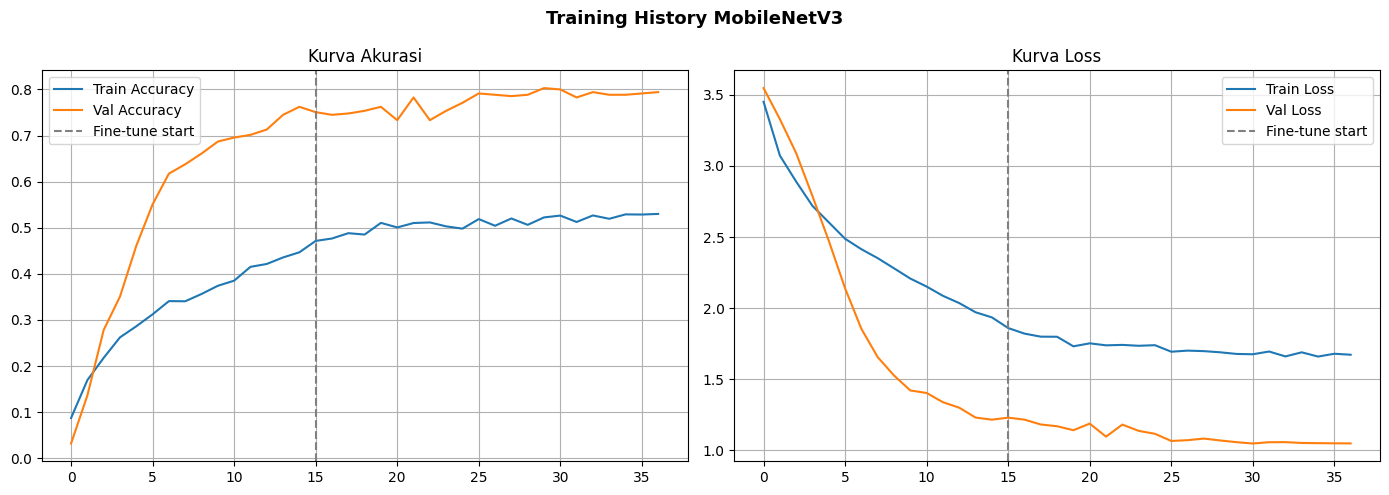

In [9]:
all_acc   = h1.history['accuracy']     + h2.history['accuracy']
all_val   = h1.history['val_accuracy'] + h2.history['val_accuracy']
all_loss  = h1.history['loss']         + h2.history['loss']
all_vloss = h1.history['val_loss']     + h2.history['val_loss']
ft_start  = len(h1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(all_acc,  label='Train Accuracy')
axes[0].plot(all_val,  label='Val Accuracy')
axes[0].axvline(ft_start, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Kurva Akurasi'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(all_loss,  label='Train Loss')
axes[1].plot(all_vloss, label='Val Loss')
axes[1].axvline(ft_start, color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Kurva Loss'); axes[1].legend(); axes[1].grid(True)

plt.suptitle('Training History MobileNetV3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()


In [10]:
best_model = keras.models.load_model(MODEL_PATH)
print("Memprediksi test set...")

y_true, y_pred = [], []
for i in range(len(test_gen)):
    Xb, yb = test_gen[i]
    pred   = best_model.predict(Xb, verbose=0)
    y_pred.extend(np.argmax(pred, axis=1))
    y_true.extend(np.argmax(yb,   axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Memprediksi test set...

Test Accuracy : 0.8045 (80.45%)

Classification Report:
               precision    recall  f1-score   support

        apple       0.33      0.22      0.27         9
       banana       0.64      0.78      0.70         9
     beetroot       0.82      0.90      0.86        10
  bell pepper       0.67      0.80      0.73        10
      cabbage       0.91      1.00      0.95        10
     capsicum       0.86      0.67      0.75         9
       carrot       0.78      0.78      0.78         9
  cauliflower       1.00      1.00      1.00         9
chilli pepper       0.78      0.70      0.74        10
         corn       0.82      0.90      0.86        10
     cucumber       0.90      0.90      0.90        10
     eggplant       0.82      0.90      0.86        10
       garlic       0.64      0.90      0.75        10
       ginger       0.83      0.50      0.62        10
       grapes       0.75      1.00      0.86         9
     jalepeno       0.86      0.60    

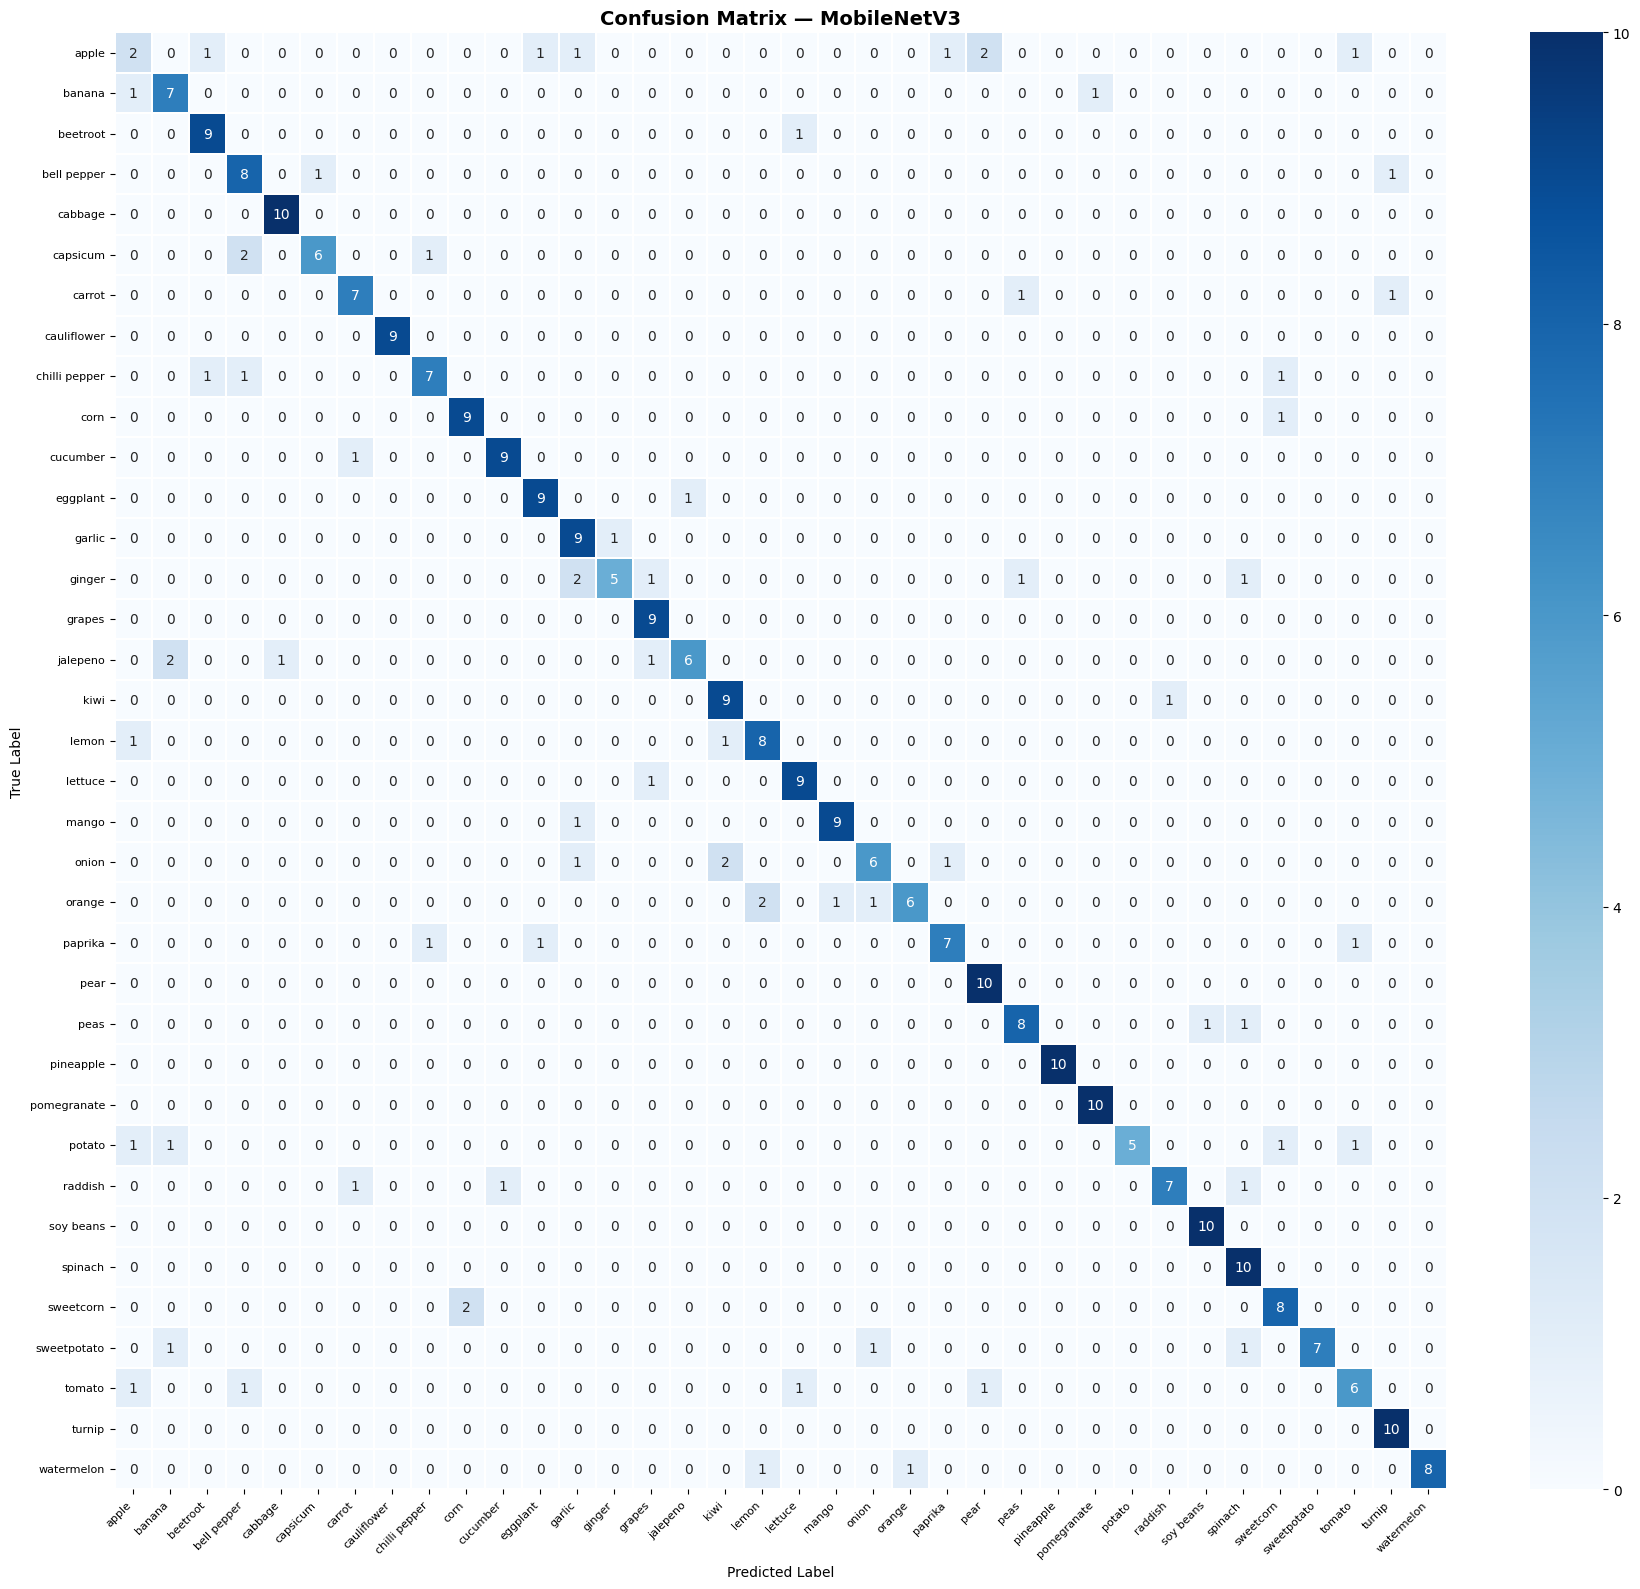

In [11]:
cm = confusion_matrix(y_true, y_pred)
fig_size = max(14, NUM_CLASSES // 2)
plt.figure(figsize=(fig_size, fig_size - 2))
sns.heatmap(cm,
            annot       = NUM_CLASSES <= 40,
            fmt         = 'd',
            cmap        = 'Blues',
            xticklabels = CLASS_NAMES,
            yticklabels = CLASS_NAMES,
            linewidths  = 0.2)
plt.title('Confusion Matrix — MobileNetV3', fontsize=14, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


## 8. Visualisasi Grad-CAM

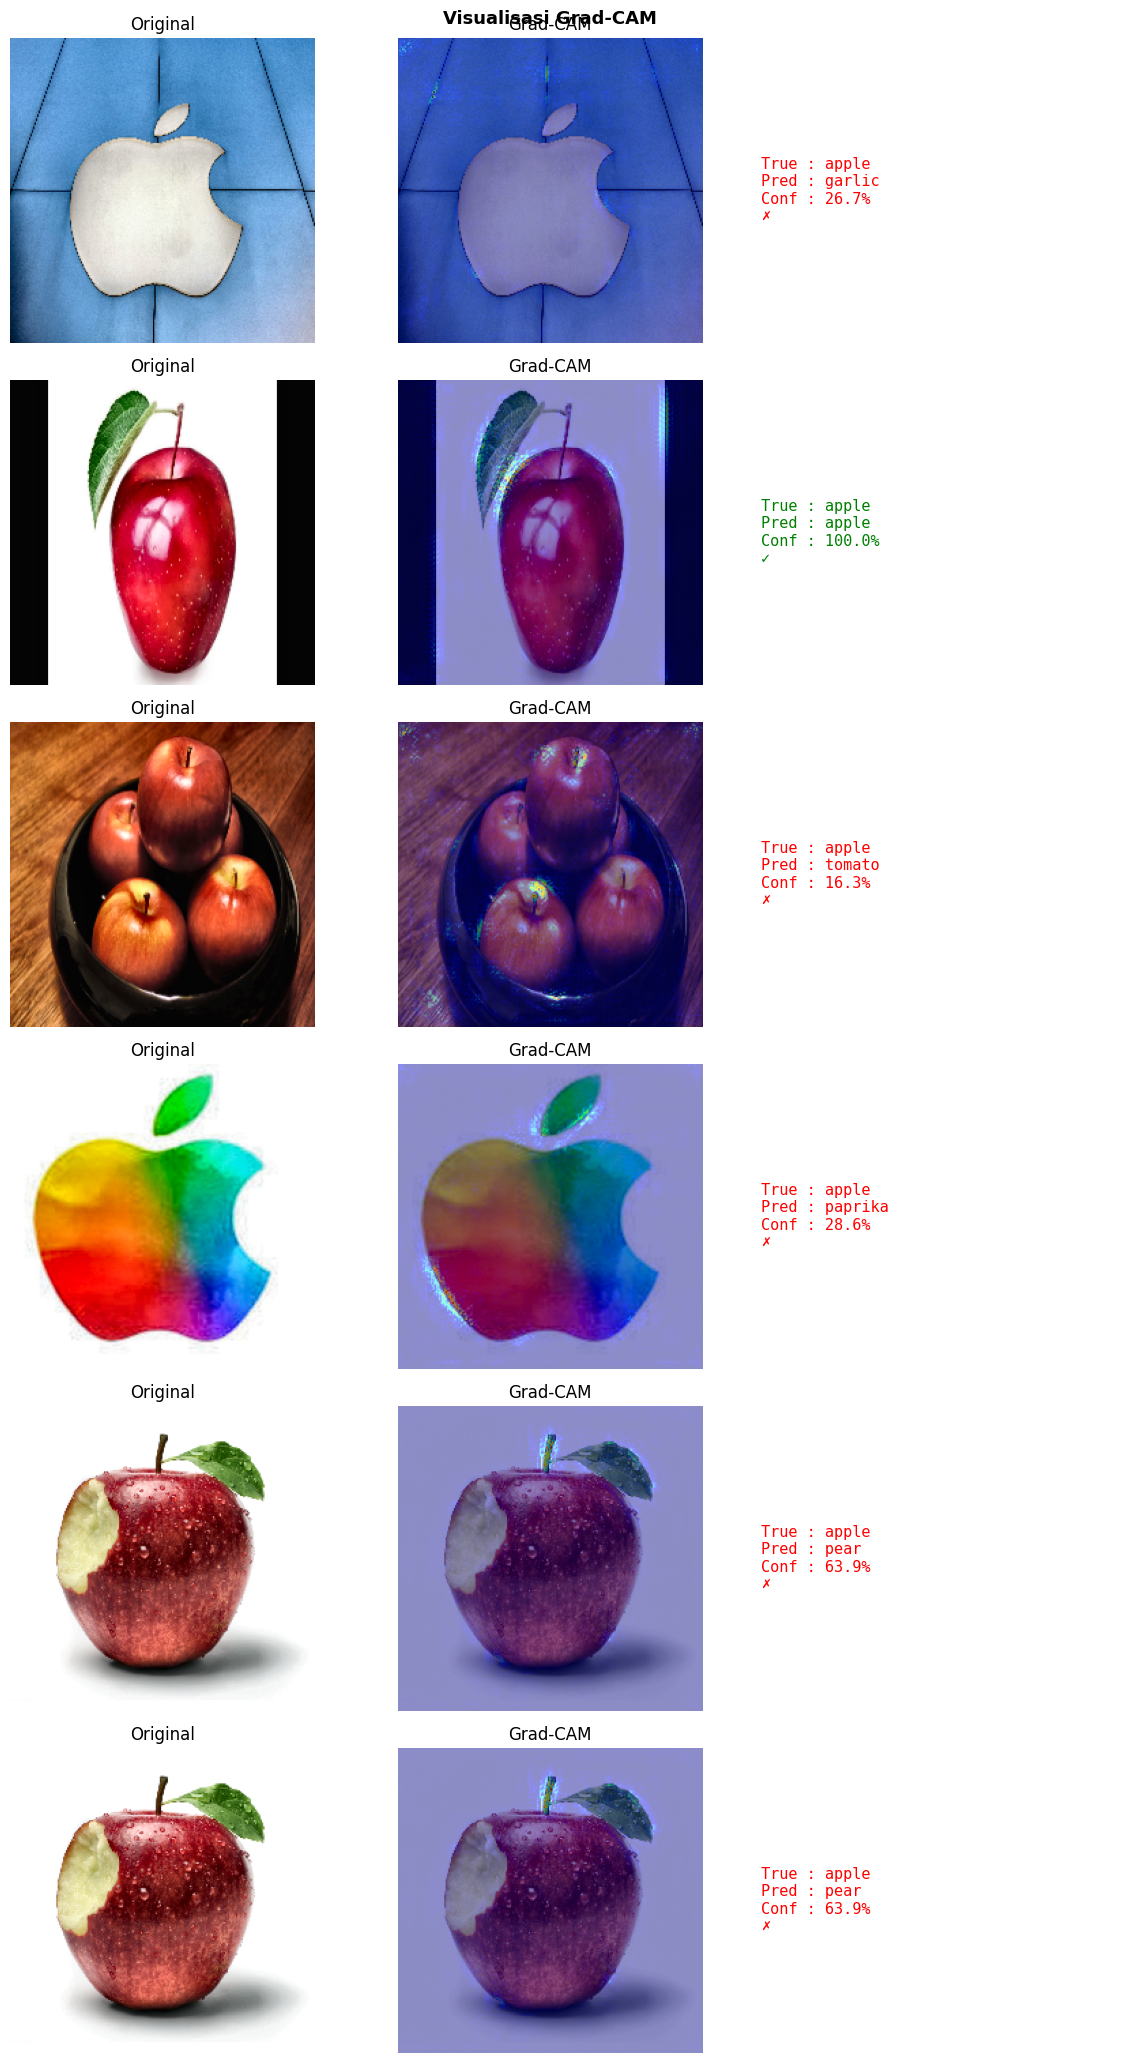

Grad-CAM selesai!


In [12]:
def get_gradcam(model, img_array, pred_index=None):
    img_var = tf.Variable(tf.cast(img_array, tf.float32), trainable=False)
    with tf.GradientTape() as tape:
        tape.watch(img_var)
        preds = model(img_var, training=False)
        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        score = preds[:, pred_index]
    grads   = tape.gradient(score, img_var)
    heatmap = tf.reduce_mean(tf.abs(grads[0]), axis=-1)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_index

def overlay_cam(img_rgb, heatmap, alpha=0.45):
    h = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    c = cv2.applyColorMap(np.uint8(255 * h), cv2.COLORMAP_JET)
    c = cv2.cvtColor(c, cv2.COLOR_BGR2RGB)
    return (c * alpha + img_rgb * (1 - alpha)).astype(np.uint8)

Xb, yb = test_gen[0]
n_show  = min(6, len(Xb))

fig, axes = plt.subplots(n_show, 3, figsize=(12, n_show * 3.5))
for i in range(n_show):
    img_exp           = np.expand_dims(Xb[i], 0)
    heatmap, pred_idx = get_gradcam(best_model, img_exp)
    img_uint          = (Xb[i] * 255).astype(np.uint8)
    overlay           = overlay_cam(img_uint, heatmap)

    true_lbl = CLASS_NAMES[np.argmax(yb[i])]
    pred_lbl = CLASS_NAMES[pred_idx]
    conf     = float(best_model.predict(img_exp, verbose=0)[0][pred_idx])
    status   = "✓" if pred_lbl == true_lbl else "✗"

    axes[i,0].imshow(img_uint); axes[i,0].set_title("Original");  axes[i,0].axis('off')
    axes[i,1].imshow(overlay);  axes[i,1].set_title("Grad-CAM"); axes[i,1].axis('off')
    axes[i,2].axis('off')
    axes[i,2].text(0.05, 0.5,
        f"True : {true_lbl}\nPred : {pred_lbl}\nConf : {conf:.1%}\n{status}",
        fontsize=11, va='center', family='monospace',
        color='green' if status == '✓' else 'red')

plt.suptitle('Visualisasi Grad-CAM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("gradcam_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM selesai!")


## 9. Simpan Model & Artefak

In [13]:
with open("class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f)

print("Artefak yang dihasilkan:")
for fname in [MODEL_PATH, "class_names.json",
              "preprocessing_visualization.png",
              "training_curves.png",
              "confusion_matrix.png",
              "gradcam_visualization.png"]:
    if os.path.exists(fname):
        size = os.path.getsize(fname) / 1024
        print(f"  ✓ {fname} ({size:.1f} KB)")

from google.colab import files
for fname in [MODEL_PATH, "class_names.json"]:
    if os.path.exists(fname):
        files.download(fname)
        print(f"Downloaded: {fname}")


Artefak yang dihasilkan:
  ✓ mobilenetv3_buah_sayur.keras (27624.5 KB)
  ✓ class_names.json (0.4 KB)
  ✓ preprocessing_visualization.png (1411.1 KB)
  ✓ training_curves.png (108.4 KB)
  ✓ confusion_matrix.png (268.5 KB)
  ✓ gradcam_visualization.png (2820.2 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: mobilenetv3_buah_sayur.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: class_names.json
